In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState, parityTransform


In [2]:
def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [3]:
path = "./configs/400kSteps.hdf5"
meta = sim.distillation.readDistillMeta(path)

In [4]:
mom0Basis = [triplet(MesonOp("g5",DNum=0,momk=0)),triplet(MesonOp("g5",DNum=2,momk=0)),triplet(MesonOp("gx"))]
mom1Basis = [triplet(MesonOp("g5",DNum=0,momk=1)),triplet(MesonOp("g5",DNum=2,momk=1)),triplet(MesonOp("gx",momk=1))]
mom2Basis = [triplet(MesonOp("g5",DNum=0,momk=2)),triplet(MesonOp("g5",DNum=2,momk=2)),triplet(MesonOp("gx",momk=2))]
mom3Basis = [triplet(MesonOp("g5",DNum=0,momk=3)),triplet(MesonOp("g5",DNum=2,momk=3)),triplet(MesonOp("gx",momk=3))]

momentumBases = [mom0Basis,mom1Basis,mom2Basis,mom3Basis]

In [5]:
gevpTi = 2

massOuts = []

for basis in momentumBases:
    data_p = sim.GEVP.measureEnsemble(path,(meta.configIndices)[::50],basis)
    data_m = sim.GEVP.measureEnsemble(path,(meta.configIndices)[::50],[parityTransform(op) for op in basis])

    data = {"conn": 0.5*(data_p["conn"] + data_m["conn"]), "disc": data_p["disc"]}  

    mass = sim.GEVP.bootstrapEnsemble(data,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=0,
                                  fitT=[2,7], withAmp=True))

    massOuts.append(mass)

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

...

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

In [6]:
masses = np.array([m[0][0][0] for m in massOuts])
massesErr = np.mean(np.array([m[1][0][0] for m in massOuts]).T, axis=0)

highMasses =  np.array([m[0][1][0] for m in massOuts])
highMassesErr =  np.mean(np.array([m[1][1][0] for m in massOuts]).T, axis=0)

In [7]:
masses

array([0.53988822, 0.65771401, 0.89614084, 1.15327902])

Text(0.5, 1.0, '$\\pi$ Disp. Rel: $N_t$:32, $N_x$:16, $\\beta$:10.0, $m_q$:0.2')

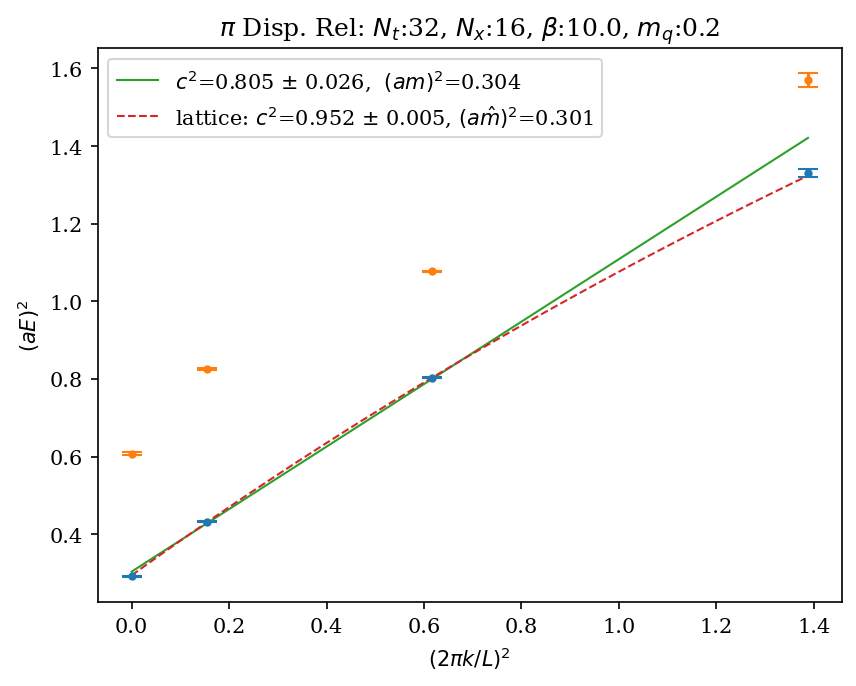

In [8]:
ks = np.array([0,1,2,3])
ps = (2 * np.pi*ks)/(meta.dimx)

fineKs = np.linspace(0,3,100)
pf = ((2 * np.pi*fineKs)/(meta.dimx))**2

sig = 2*masses*massesErr
coeff, cov = np.polyfit(ps**2,masses**2,deg=1,cov=True,w=1/sig)
c2 , m2 = coeff
dc2 = np.sqrt(cov[0,0])

sigLat = 2*np.sinh(masses)*massesErr      # d/dE [4 sinh^2(E/2)] = 2 sinh(E)

coeffLat, covLat = np.polyfit(4*np.sin(ps/2)**2,4*np.sinh(masses/2)**2,deg=1,cov=True,w=1/sig)
c2Lat , m2Lat = coeffLat
dc2Lat = np.sqrt(covLat[0,0])

pfLin = np.sqrt(pf)                                  # pf is the (ap)^2 grid -> ap values

Ehat2 = m2Lat + c2Lat * 4*np.sin(pfLin/2)**2         # lattice-form prediction
Elat  = 2*np.arcsinh(np.sqrt(Ehat2)/2)               # invert 4sinh^2(aE/2) = Ehat2

plt.figure(dpi=150)

plt.errorbar(x=ps**2,y=masses**2,yerr=2*masses*massesErr,fmt=".",capsize=5)
plt.errorbar(x=ps**2,y=highMasses**2,yerr=2*highMasses*highMassesErr,fmt=".",capsize=5)
plt.plot(pf, m2 + c2*pf, lw=1,
         label=rf"$c^2$={c2:.3f} $\pm$ {dc2:.3f},  $(am)^2$={m2:.3f}")

plt.plot(pf, Elat**2, lw=1, ls="--",
         label=rf"lattice: $c^2$={c2Lat:.3f} $\pm$ {dc2Lat:.3f}, $(a\hat m)^2$={m2Lat:.3f}")

plt.xlabel(r"$(2 \pi k/L)^2$")
plt.ylabel("$(aE)^2$")
plt.legend()

plt.title(rf"$\pi$ Disp. Rel: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

In [9]:
mom0Basis = [singlet(MesonOp("g5",DNum=0,momk=0)),singlet(MesonOp("g5",DNum=2,momk=0)), singlet(MesonOp("id",DNum=1,momk=0))]
mom1Basis = [singlet(MesonOp("g5",DNum=0,momk=1)),singlet(MesonOp("g5",DNum=2,momk=1)), singlet(MesonOp("id",DNum=1,momk=1))]
mom2Basis = [singlet(MesonOp("g5",DNum=0,momk=2)),singlet(MesonOp("g5",DNum=2,momk=2)), singlet(MesonOp("id",DNum=1,momk=2))]
mom3Basis = [singlet(MesonOp("g5",DNum=0,momk=3)),singlet(MesonOp("g5",DNum=2,momk=3)), singlet(MesonOp("id",DNum=1,momk=3))]

momentumBases = [mom0Basis,mom1Basis,mom2Basis,mom3Basis]

In [10]:
gevpTi = 2

massOuts = []

#only do positive parity because combining disconnected parts is hard
for basis in momentumBases:
    data_p = sim.GEVP.measureEnsemble(path,(meta.configIndices)[::20],basis)

    # ground state: 2x2 g5-tower sub-block. The id-D1 op adds a sign-crossing
    # sinh mode (unfittable by construction) that only adds noise to E0.
    mrG = sim.GEVP.massReduce(ti=gevpTi, shift=1, fitT=[(3,8),(2,6)], withAmp=True)
    ground = sim.GEVP.bootstrapEnsemble(data_p, reduce=lambda C: mrG(C[:2,:2,:]))

    # excited state: full 3-op basis (id-D1 sharpens E1 considerably);
    # per-state windows, sinh mode reports NaN harmlessly
    full = sim.GEVP.bootstrapEnsemble(data_p, reduce=sim.GEVP.massReduce(ti=gevpTi,
                shift=1, fitT=[(3,8),(2,6),(2,4)], withAmp=True))

    massOuts.append((ground, full))

Measuring configs:   0%|          | 0/4000 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:144: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 64% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


Measuring configs:   0%|          | 0/4000 [00:00<?, ?it/s]

...

Measuring configs:   0%|          | 0/4000 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:144: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 1% (components failing >5%: 0)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:144: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 8% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


In [11]:
# ground state: state 0 of the 2x2 sub-block reduce
masses    = np.array([g[0][0, 0]              for g, f in massOuts])
massesErr = np.array([g[1][:, 0, 0].mean()    for g, f in massOuts])

# first excited: energy-ordered finite state from the full 3-op reduce
# (labels can shuffle when a basis contains an unfittable mode, so order by E)
def firstExcited(f):
    E   = f[0][:, 0]
    err = f[1][:, :, 0].mean(axis=0)
    order = np.argsort(np.where(np.isfinite(E), E, np.inf))
    return E[order[1]], err[order[1]]

pairs = np.array([firstExcited(f) for g, f in massOuts])
highMasses, highMassesErr = pairs[:, 0], pairs[:, 1]

In [12]:
masses

array([0.5868358 , 0.69515827, 0.88787108, 1.07239223])

(0.0, 2.0)

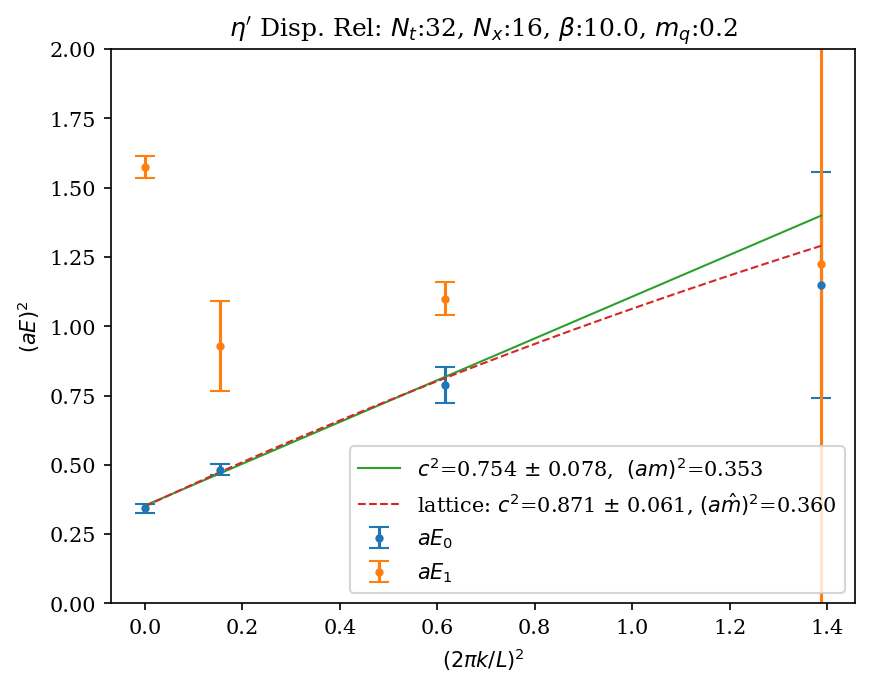

In [14]:
ks = np.array([0,1,2,3])
ps = (2 * np.pi*ks)/(meta.dimx)

fineKs = np.linspace(0,3,100)
pf = ((2 * np.pi*fineKs)/(meta.dimx))**2

# fit only momenta whose mass extraction succeeded (and is worth trusting)
good = np.isfinite(masses) & np.isfinite(massesErr)

sig = 2*masses*massesErr
coeff, cov = np.polyfit(ps[good]**2,masses[good]**2,deg=1,cov=True,w=1/sig[good])
c2 , m2 = coeff
dc2 = np.sqrt(cov[0,0])

sigLat = 2*np.sinh(masses)*massesErr      # d/dE [4 sinh^2(E/2)] = 2 sinh(E)

coeffLat, covLat = np.polyfit(4*np.sin(ps[good]/2)**2,4*np.sinh(masses[good]/2)**2,
                              deg=1,cov=True,w=1/sigLat[good])
c2Lat , m2Lat = coeffLat
dc2Lat = np.sqrt(covLat[0,0])

pfLin = np.sqrt(pf)                                  # pf is the (ap)^2 grid -> ap values

Ehat2 = m2Lat + c2Lat * 4*np.sin(pfLin/2)**2         # lattice-form prediction
Elat  = 2*np.arcsinh(np.sqrt(Ehat2)/2)               # invert 4sinh^2(aE/2) = Ehat2

plt.figure(dpi=150)

plt.errorbar(x=ps[good]**2,y=masses[good]**2,yerr=(2*masses*massesErr)[good],fmt=".",capsize=5,label="$aE_0$")
plt.errorbar(x=ps**2,y=highMasses**2,yerr=2*highMasses*highMassesErr,fmt=".",capsize=5,label="$aE_1$")
plt.plot(pf, m2 + c2*pf, lw=1,
         label=rf"$c^2$={c2:.3f} $\pm$ {dc2:.3f},  $(am)^2$={m2:.3f}")

plt.plot(pf, Elat**2, lw=1, ls="--",
         label=rf"lattice: $c^2$={c2Lat:.3f} $\pm$ {dc2Lat:.3f}, $(a\hat m)^2$={m2Lat:.3f}")

plt.xlabel(r"$(2 \pi k/L)^2$")
plt.ylabel("$(aE)^2$")
plt.legend()

plt.title(rf"$\eta'$ Disp. Rel: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")
plt.ylim([0,2])